In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

NON_OVERFIT_FOLDS = [
    "fold_00",
    "fold_01",
    "fold_04",
    "fold_05",
    "fold_06",
    "fold_08",
    "fold_10",
]
FOLDS = [f"fold_{i:02d}" for i in range(12)]

HEIHC_ROOT = Path("../output/heihc_fold")
SAROPT_ROOT = Path("../output/saropt_fold")


def load_mmd(fold_dir):
    base = fold_dir / "val_costs" / "resnet50"

    def _read(name):
        df = pd.read_csv(base / name, index_col=0)
        cols = df.columns.tolist()
        return float(df.loc[cols[0], cols[1]])

    return _read("gaussian_mmd_mean.csv"), _read("gaussian_mmd_std.csv")


def load_psnr(fold_dir):
    df = pd.read_csv(fold_dir / "metrics.csv")
    return float(df[df["Epoch"] == "test"].iloc[0]["PSNR"])


def build_df(root, FOLDS):
    rows = []
    for fold in FOLDS:
        fold_dir = root / fold
        mean, std = load_mmd(fold_dir)
        rows.append(
            {
                "fold": fold,
                "mmd_mean": mean,
                "mmd_std": std,
                "PSNR": load_psnr(fold_dir),
            }
        )
    return pd.DataFrame(rows)


df_heihc = build_df(HEIHC_ROOT, FOLDS)
df_heihc_nonOverfit = build_df(HEIHC_ROOT, NON_OVERFIT_FOLDS)
df_saropt = build_df(SAROPT_ROOT, FOLDS)

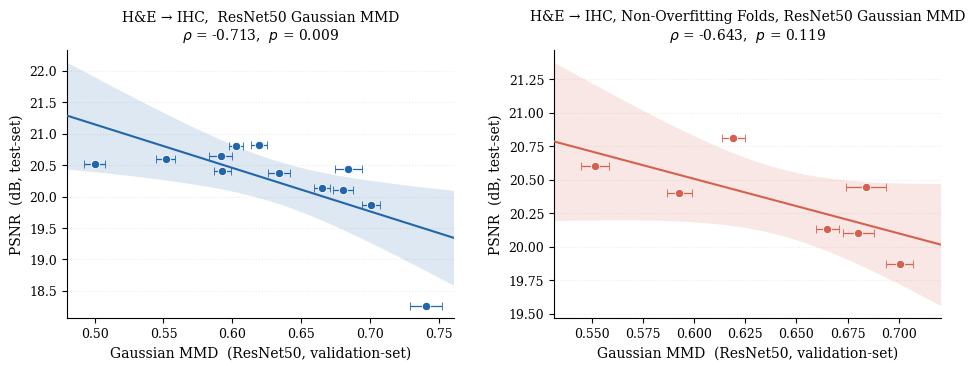

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import spearmanr, t as t_dist

plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

BLUE = "#2166AC"
RED = "#D6604D"


def regression_band(x, y, x_grid, alpha=0.05):
    """Return (y_fit, y_lo, y_hi) on x_grid — 95 % confidence band for the mean response."""
    n = len(x)
    m, b = np.polyfit(x, y, 1)
    y_hat = m * x + b
    mse = np.sum((y - y_hat) ** 2) / (n - 2)
    x_mean = x.mean()
    sxx = np.sum((x - x_mean) ** 2)
    t_crit = t_dist.ppf(1 - alpha / 2, df=n - 2)
    se_grid = np.sqrt(mse * (1 / n + (x_grid - x_mean) ** 2 / sxx))
    y_fit = m * x_grid + b
    return y_fit, y_fit - t_crit * se_grid, y_fit + t_crit * se_grid


def scatter_plot(ax, df, color, title, xlabel):
    x = df["mmd_mean"].values
    xe = df["mmd_std"].values
    y = df["PSNR"].values
    rho, p = spearmanr(x, y)

    # error bars (bootstrap ±1 σ on the MMD estimate)
    ax.errorbar(
        x,
        y,
        xerr=xe,
        fmt="o",
        color=color,
        markersize=6,
        ecolor=color,
        elinewidth=0.9,
        capsize=3,
        capthick=0.9,
        markeredgecolor="white",
        markeredgewidth=0.6,
        zorder=4,
    )

    # regression line + 95 % confidence band
    x_grid = np.linspace(x.min() - 0.02, x.max() + 0.02, 300)
    y_fit, y_lo, y_hi = regression_band(x, y, x_grid)
    ax.plot(x_grid, y_fit, color=color, lw=1.5, zorder=3)
    ax.fill_between(x_grid, y_lo, y_hi, color=color, alpha=0.15, zorder=2, linewidth=0)

    p_str = f"{p:.3f}" if p >= 0.001 else f"{p:.2e}"
    ax.set_title(
        title + "\n" r"$\rho$" + f" = {rho:.3f},  $p$ = {p_str}",
        fontsize=10,
        pad=8,
    )
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("PSNR  (dB, test-set)", fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(axis="y", alpha=0.25, linestyle=":")
    ax.set_xlim(x_grid[0], x_grid[-1])


fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

scatter_plot(
    axes[0],
    df_heihc,
    BLUE,
    title="H&E \u2192 IHC,  ResNet50 Gaussian MMD",
    xlabel="Gaussian MMD  (ResNet50, validation-set)",
)
scatter_plot(
    axes[1],
    df_heihc_nonOverfit,
    RED,
    title="H&E \u2192 IHC, Non-Overfitting Folds, ResNet50 Gaussian MMD",
    xlabel="Gaussian MMD  (ResNet50, validation-set)",
)

fig.tight_layout(pad=2.5)
plt.show()